In [114]:
import pandas as pd
df = pd.read_parquet('/Users/lithrur/Desktop/Coding projects/hackathon_2025_ai/dataset/DECENTRATHON_3.0.parquet')
df.to_csv('/Users/lithrur/Desktop/Coding projects/hackathon_2025_ai/dataset/dataset.csv', index=False)

print("Loaded rows:", len(df))

# Cell 2: inspect types & size
print(df.info())


Loaded rows: 11536850
<class 'pandas.core.frame.DataFrame'>
Index: 11536850 entries, 0 to 11536849
Data columns (total 16 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_id          string        
 1   transaction_timestamp   datetime64[us]
 2   card_id                 Int64         
 3   expiry_date             string        
 4   issuer_bank_name        object        
 5   merchant_id             Int64         
 6   merchant_mcc            Int64         
 7   mcc_category            string        
 8   merchant_city           string        
 9   transaction_type        string        
 10  transaction_amount_kzt  Float64       
 11  original_amount         Float64       
 12  transaction_currency    string        
 13  acquirer_country_iso    string        
 14  pos_entry_mode          string        
 15  wallet_type             string        
dtypes: Float64(2), Int64(3), datetime64[us](1), object(1), string(9)
memory

In [115]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 11536850 entries, 0 to 11536849
Data columns (total 16 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_id          string        
 1   transaction_timestamp   datetime64[us]
 2   card_id                 Int64         
 3   expiry_date             string        
 4   issuer_bank_name        object        
 5   merchant_id             Int64         
 6   merchant_mcc            Int64         
 7   mcc_category            string        
 8   merchant_city           string        
 9   transaction_type        string        
 10  transaction_amount_kzt  Float64       
 11  original_amount         Float64       
 12  transaction_currency    string        
 13  acquirer_country_iso    string        
 14  pos_entry_mode          string        
 15  wallet_type             string        
dtypes: Float64(2), Int64(3), datetime64[us](1), object(1), string(9)
memory usage: 7.1 GB


In [116]:
df['card_id'] = df['card_id'] - 9999
# Move 'card_id' to the first column
cols = ['card_id'] + [col for col in df.columns if col != 'card_id']
df = df[cols]

In [117]:
columns_to_drop = ['transaction_id', 'issuer_bank_name',]  # Example: ['timestamp', 'user_id']
df = df.drop(columns=columns_to_drop)

df

,card_id,transaction_timestamp,expiry_date,merchant_id,merchant_mcc,mcc_category,merchant_city,transaction_type,transaction_amount_kzt,original_amount,transaction_currency,acquirer_country_iso,pos_entry_mode,wallet_type
0,1,2023-08-12 23:14:19.043176,09/26,50359,5499,Grocery & Food Markets,Shymkent,POS,1237.66,<NA>,KZT,KAZ,Contactless,Apple Pay
1,1,2023-08-12 17:07:08.641030,09/26,50359,5499,Grocery & Food Markets,Shymkent,POS,2328.03,<NA>,KZT,KAZ,QR_Code,Bank's QR
2,1,2023-08-12 08:45:32.946846,09/26,50214,4814,Utilities & Bill Payments,Almaty,BILL_PAYMENT,53871.78,<NA>,KZT,KAZ,<NA>,<NA>
3,1,2023-08-12 10:20:20.242510,09/26,50279,8011,Pharmacies & Health,Shymkent,POS,22501.56,<NA>,KZT,KAZ,Contactless,Apple Pay
4,1,2023-08-12 00:42:00.556252,09/26,50332,5499,Grocery & Food Markets,Almaty,POS,1224.04,<NA>,KZT,KAZ,QR_Code,Bank's QR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11536845,2000,2024-12-31 17:49:20.692872,01/28,<NA>,<NA>,Unknown,<NA>,ATM_WITHDRAWAL,57000.0,<NA>,KZT,KAZ,Contactless,<NA>
11536846,2000,2024-12-31 12:57:38.022726,01/28,50214,5311,General Retail & Department,Almaty,ECOM,18661.51,<NA>,KZT,KAZ,ECOM,Google Pay
11536847,2000,2024-12-31 14:32:13.832646,01/28,50306,4814,Utilities & Bill Payments,Almaty,POS,6161.15,<NA>,KZT,KAZ,Chip,<NA>
11536848,2000,2024-12-31 08:54:37.277956,01/28,<NA>,<NA>,Unknown,<NA>,ATM_WITHDRAWAL,29000.0,<NA>,KZT,KAZ,Chip,<NA>


In [118]:
df = df.drop(columns=['original_amount'])

In [119]:
df

,card_id,transaction_timestamp,expiry_date,merchant_id,merchant_mcc,mcc_category,merchant_city,transaction_type,transaction_amount_kzt,transaction_currency,acquirer_country_iso,pos_entry_mode,wallet_type
0,1,2023-08-12 23:14:19.043176,09/26,50359,5499,Grocery & Food Markets,Shymkent,POS,1237.66,KZT,KAZ,Contactless,Apple Pay
1,1,2023-08-12 17:07:08.641030,09/26,50359,5499,Grocery & Food Markets,Shymkent,POS,2328.03,KZT,KAZ,QR_Code,Bank's QR
2,1,2023-08-12 08:45:32.946846,09/26,50214,4814,Utilities & Bill Payments,Almaty,BILL_PAYMENT,53871.78,KZT,KAZ,<NA>,<NA>
3,1,2023-08-12 10:20:20.242510,09/26,50279,8011,Pharmacies & Health,Shymkent,POS,22501.56,KZT,KAZ,Contactless,Apple Pay
4,1,2023-08-12 00:42:00.556252,09/26,50332,5499,Grocery & Food Markets,Almaty,POS,1224.04,KZT,KAZ,QR_Code,Bank's QR
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11536845,2000,2024-12-31 17:49:20.692872,01/28,<NA>,<NA>,Unknown,<NA>,ATM_WITHDRAWAL,57000.0,KZT,KAZ,Contactless,<NA>
11536846,2000,2024-12-31 12:57:38.022726,01/28,50214,5311,General Retail & Department,Almaty,ECOM,18661.51,KZT,KAZ,ECOM,Google Pay
11536847,2000,2024-12-31 14:32:13.832646,01/28,50306,4814,Utilities & Bill Payments,Almaty,POS,6161.15,KZT,KAZ,Chip,<NA>
11536848,2000,2024-12-31 08:54:37.277956,01/28,<NA>,<NA>,Unknown,<NA>,ATM_WITHDRAWAL,29000.0,KZT,KAZ,Chip,<NA>


In [120]:
import pandas as pd
import numpy as np

# assume df already has 11 million rows and:
# df['transaction_timestamp'] is dtype datetime64[us]

# 1) vectorized extraction of hour (0–23)
hours = df['transaction_timestamp'].dt.hour.values  
#    → this is a NumPy array of length 11 000 000, very fast

# 2) build a 24-element lookup table
hour_labels = np.array(['Night'] * 24, dtype=object)
hour_labels[ 5:12] = 'Morning'    # 05:00–11:59
hour_labels[12:17] = 'Afternoon'  # 12:00–16:59
hour_labels[17:21] = 'Evening'    # 17:00–20:59
# hours 21–23, 0–4 remain 'Night'

# 3) index into it
df['time_of_day'] = hour_labels[hours]

# 4) (optional) save memory by converting to a true Categorical
df['time_of_day'] = df['time_of_day'].astype('category')

# you can then drop the raw timestamp or hours if you don’t need them:
# df.drop(columns=['transaction_timestamp'], inplace=True)

In [121]:
df.drop(columns=['transaction_timestamp'], inplace=True)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11536850 entries, 0 to 11536849
Data columns (total 13 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   card_id                 Int64   
 1   expiry_date             string  
 2   merchant_id             Int64   
 3   merchant_mcc            Int64   
 4   mcc_category            string  
 5   merchant_city           string  
 6   transaction_type        string  
 7   transaction_amount_kzt  Float64 
 8   transaction_currency    string  
 9   acquirer_country_iso    string  
 10  pos_entry_mode          string  
 11  wallet_type             string  
 12  time_of_day             category
dtypes: Float64(1), Int64(3), category(1), string(8)
memory usage: 1.2 GB


In [123]:
pip install umap-learn hdbscan

91870.27s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Segment sizes (card counts):
cluster
-1    721
 0    120
 1    958
 2    201
Name: count, dtype: int64
Segment behavioral features:
         transaction_amount_sum  transaction_amount_mean  \
cluster                                                    
-1             181416920.937906             24689.185148   
 0             257722977.353917             19234.863014   
 1               49340045.90166             19305.897208   
 2             117730946.755522             39289.065962   

         transaction_amount_std  tod_Afternoon  tod_Evening  tod_Morning  \
cluster                                                                    
-1                 73272.410393       0.268664     0.247990     0.341066   
 0                  54923.06094       0.272810     0.246172     0.336986   
 1                 44580.278952       0.275140     0.242659     0.338770   
 2                150744.004978       0.275205     0.244828     0.337697   

         tod_Night  
cluster             
-1      

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


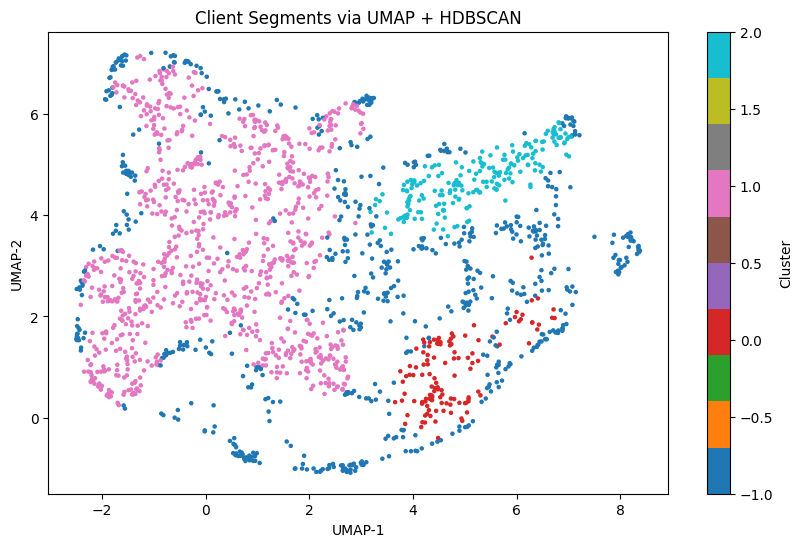

In [124]:

# Client Segmentation Pipeline (non-KMeans) - Final Version with correct time_of_day aggregation
import pandas as pd
import numpy as np
import umap
import hdbscan
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. Assume df_txn is pre-loaded DataFrame with transactions, including these columns:
#    'card_id', 'transaction_amount_kzt', 'time_of_day'

# 3. Aggregate transaction amounts per client
amount_agg = (
    df_txn
    .groupby('card_id')['transaction_amount_kzt']
    .agg(['sum', 'mean', 'std'])
    .fillna(0)
)
amount_agg.columns = ['transaction_amount_sum', 'transaction_amount_mean', 'transaction_amount_std']

# 4. One-hot encode time_of_day and get distribution per client
time_ohe = pd.get_dummies(df_txn['time_of_day'], prefix='tod')
time_ohe['card_id'] = df_txn['card_id']
time_dist = time_ohe.groupby('card_id').mean().fillna(0)

# 5. Combine features into a single DataFrame
features = amount_agg.join(time_dist, how='left').fillna(0)

# 6. Prepare feature matrix X (drop index)
X = features.reset_index(drop=True)
feature_cols = X.columns.tolist()

# 7. Preprocessing: scale all numeric features (including time_of_day dummies)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), feature_cols)
], remainder='drop')

# 8. Build full pipeline: preprocessing -> UMAP -> HDBSCAN
pipeline = Pipeline([
    ('prep', preprocessor),
    ('umap', umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_SEED)),
    ('cluster', hdbscan.HDBSCAN(min_cluster_size=50, gen_min_span_tree=True, prediction_data=True))
])

# 9. Slice pipeline to omit clustering step for embedding
umap_only = pipeline[:-1]

# 10. Fit-transform to get 2D embedding
X_embedded = umap_only.fit_transform(X)

# 11. Apply HDBSCAN clustering
clusterer = pipeline.named_steps['cluster']
labels = clusterer.fit_predict(X_embedded)

# 12. Attach cluster labels and embedding to results
seg_df = features.copy()
seg_df['cluster'] = labels
seg_df['umap_x'] = X_embedded[:, 0]
seg_df['umap_y'] = X_embedded[:, 1]

# 13. Segment sizes
print("Segment sizes (card counts):")
print(seg_df['cluster'].value_counts().sort_index())

# 14. Behavioral features per segment
segment_features = seg_df.groupby('cluster')[['transaction_amount_sum',
                                                'transaction_amount_mean',
                                                'transaction_amount_std'] +
                                               [col for col in seg_df.columns if col.startswith('tod_')]
                                              ].mean()
print("Segment behavioral features:")
print(segment_features)

# 15. Visualization of segments
plt.figure(figsize=(10, 6))
scatter = plt.scatter(seg_df['umap_x'], seg_df['umap_y'], c=seg_df['cluster'], cmap='tab10', s=5)
plt.title('Client Segments via UMAP + HDBSCAN')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(scatter, label='Cluster')
plt.show()

# 16. Optionally save the segmentation result
# seg_df.to_csv('client_segments_hdbscan.csv', index=False)


In [125]:
cols = ['transaction_amount_sum',
        'transaction_amount_mean',
        'transaction_amount_std'] + [c for c in seg_df.columns if c.startswith('tod_')]

segment_features = seg_df.groupby('cluster')[cols].mean()
print(segment_features)

         transaction_amount_sum  transaction_amount_mean  \
cluster                                                    
-1             181416920.937906             24689.185148   
 0             257722977.353917             19234.863014   
 1               49340045.90166             19305.897208   
 2             117730946.755522             39289.065962   

         transaction_amount_std  tod_Afternoon  tod_Evening  tod_Morning  \
cluster                                                                    
-1                 73272.410393       0.268664     0.247990     0.341066   
 0                  54923.06094       0.272810     0.246172     0.336986   
 1                 44580.278952       0.275140     0.242659     0.338770   
 2                150744.004978       0.275205     0.244828     0.337697   

         tod_Night  
cluster             
-1        0.142280  
 0        0.144032  
 1        0.143431  
 2        0.142270  


/var/folders/f3/ns77n8n1697cr4j7_f2yh09w0000gn/T/ipykernel_39420/1870873444.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['expiry_date'] = pd.to_datetime(df['expiry_date'], errors='coerce')
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Segment sizes (cluster_hdb):
cluster_hdb
0      98
1      82
2     200
3      83
4    1295
5     171
6      71
Name: count, dtype: int64

Behavioral features (cluster_hdb):
             acquirer_country_iso_ARE  acquirer_country_iso_ARM  \
cluster_hdb                                                       
0                                 0.0                       0.0   
1                            0.000024                  0.000004   
2                                 0.0                       0.0   
3                            0.000042                  0.000026   
4                            0.000102                   0.00009   
5                                 0.0                       0.0   
6                             0.00001                  0.000006   

             acquirer_country_iso_BLR  acquirer_country_iso_CHN  \
cluster_hdb                                                       
0                                 0.0                       0.0   
1                     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


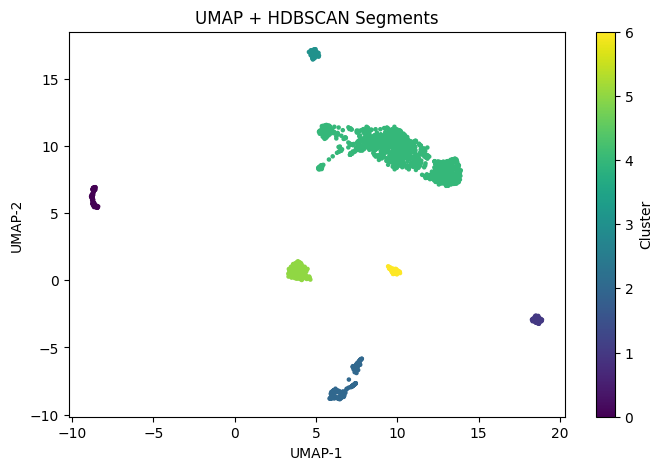

Segment sizes (cluster_gmm):
cluster_gmm
0     269
1    1295
2      82
3     271
4      83
Name: count, dtype: int64

Behavioral features (cluster_gmm):
             acquirer_country_iso_ARE  acquirer_country_iso_ARM  \
cluster_gmm                                                       
0                                 0.0                       0.0   
1                            0.000102                   0.00009   
2                            0.000024                  0.000004   
3                            0.000003                  0.000002   
4                            0.000042                  0.000026   

             acquirer_country_iso_BLR  acquirer_country_iso_CHN  \
cluster_gmm                                                       
0                                 0.0                       0.0   
1                             0.00009                    0.0001   
2                            0.000003                  0.000006   
3                            0.000002     

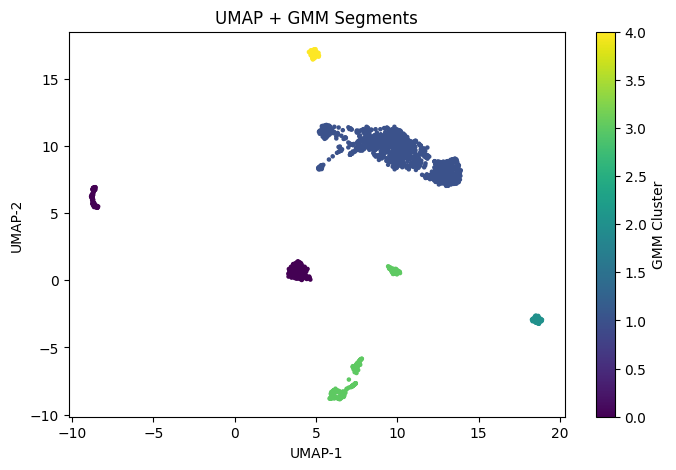

In [126]:

# Client Segmentation Pipeline (non-KMeans) - Using All Provided Features
import pandas as pd
import numpy as np
import umap
import hdbscan
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. Assume df is a pre-loaded DataFrame with exactly these columns:
#    ['card_id', 'expiry_date', 'merchant_id', 'merchant_mcc',
#     'mcc_category', 'merchant_city', 'transaction_type',
#     'transaction_amount_kzt', 'transaction_currency',
#     'acquirer_country_iso', 'pos_entry_mode', 'wallet_type',
#     'time_of_day']

# 3. Parse expiry_date as datetime and extract year-month as categorical
df['expiry_date'] = pd.to_datetime(df['expiry_date'], errors='coerce')
df['expiry_year_month'] = df['expiry_date'].dt.to_period('M').astype(str)

# 4. Numeric aggregations per client
numeric_agg = df.groupby('card_id').agg(
    transaction_sum=('transaction_amount_kzt', 'sum'),
    transaction_mean=('transaction_amount_kzt', 'mean'),
    transaction_std=('transaction_amount_kzt', 'std'),
    unique_merchant_ids=('merchant_id', 'nunique'),
    unique_merchant_mccs=('merchant_mcc', 'nunique')
).fillna(0)

# 5. Categorical distributions per client via one-hot and mean
categorical_columns = [
    'expiry_year_month', 'mcc_category', 'merchant_city', 'transaction_type',
    'transaction_currency', 'acquirer_country_iso', 'pos_entry_mode',
    'wallet_type', 'time_of_day'
]
cat_dists = []
for col in categorical_columns:
    dummies = pd.get_dummies(df[col], prefix=col)
    dummies['card_id'] = df['card_id']
    dist = dummies.groupby('card_id').mean().fillna(0)
    cat_dists.append(dist)

# 6. Combine numeric and categorical features
features = numeric_agg.copy()
for dist in cat_dists:
    features = features.join(dist, how='left')
features.fillna(0, inplace=True)

# 7. Prepare feature matrix
X = features.reset_index(drop=True)
feature_columns = X.columns.tolist()

# 8. Preprocessing: scale all features
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), feature_columns)
], remainder='drop')

# 9. UMAP embedding + HDBSCAN clustering
pipeline_hdb = Pipeline([
    ('prep', preprocessor),
    ('umap', umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                       random_state=RANDOM_SEED)),
    ('cluster', hdbscan.HDBSCAN(min_cluster_size=50,
                                gen_min_span_tree=True,
                                prediction_data=True))
])

# 10. Extract UMAP-only
umap_only = pipeline_hdb[:-1]
X_embedded = umap_only.fit_transform(X)

# 11. HDBSCAN clustering
hdb = pipeline_hdb.named_steps['cluster']
labels_hdb = hdb.fit_predict(X_embedded)

# 12. Attach HDBSCAN results
df_segments = features.copy()
df_segments['cluster_hdb'] = labels_hdb
df_segments['umap_x'] = X_embedded[:, 0]
df_segments['umap_y'] = X_embedded[:, 1]

# 13. Function to summarize segments
def summarize(df, label):
    sizes = df[label].value_counts().sort_index()
    print(f"Segment sizes ({label}):\n{sizes}\n")
    cols = df.columns.difference(['umap_x', 'umap_y'])
    summary = df.groupby(label)[cols].mean()
    print(f"Behavioral features ({label}):\n{summary}\n")

summarize(df_segments, 'cluster_hdb')

# 14. Visualize HDBSCAN segments
plt.figure(figsize=(8, 5))
plt.scatter(df_segments['umap_x'], df_segments['umap_y'],
            c=df_segments['cluster_hdb'], s=5)
plt.title('UMAP + HDBSCAN Segments')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(label='Cluster')
plt.show()

# 15. Alternative: Gaussian Mixture on UMAP embedding (5 clusters)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=RANDOM_SEED)
labels_gmm = gmm.fit_predict(X_embedded)

df_segments['cluster_gmm'] = labels_gmm
summarize(df_segments, 'cluster_gmm')

# 16. Visualize GMM segments
plt.figure(figsize=(8, 5))
plt.scatter(df_segments['umap_x'], df_segments['umap_y'],
            c=df_segments['cluster_gmm'], s=5)
plt.title('UMAP + GMM Segments')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(label='GMM Cluster')
plt.show()

# 17. Save results if needed
# df_segments.to_csv('client_segments_all.csv', index=False)

In [127]:
from sklearn.cluster import KMeans
import umap
import hdbscan

# 1) Маскируем кластер 4
mask4 = df_segments['cluster_hdb'] == 4
X4 = X[mask4.values]               # X — ваш feature matrix из предыдущей ячейки
idx4 = df_segments.index[mask4]    # индексы клиентов из кластера 4

# 2) Применяем тот же preprocessor, которым вы масштабировали весь X
X4_scaled = preprocessor.transform(X4)

# 3) Делаем новый UMAP-эмбеддинг для подвыборки
umap4 = umap.UMAP(
    n_neighbors=15, min_dist=0.1, n_components=2,
    random_state=RANDOM_SEED
)
emb4 = umap4.fit_transform(X4_scaled)

# 4A) Субкластеризация HDBSCAN
sub_hdb = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    gen_min_span_tree=True
)
labels_sub_hdb = sub_hdb.fit_predict(emb4)
df_segments.loc[idx4, 'subcluster_hdb_4'] = labels_sub_hdb

# 4B) Альтернативно: KMeans на 2 кластера
from sklearn.cluster import KMeans
k2 = KMeans(n_clusters=2, random_state=RANDOM_SEED).fit(emb4)
df_segments.loc[idx4, 'subcluster_k2_4'] = k2.labels_

# 5) Проверяем размеры новых подкластеров
print(df_segments['subcluster_hdb_4'].value_counts())
print(df_segments['subcluster_k2_4'].value_counts())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


subcluster_hdb_4
 3.0    753
 2.0    343
 1.0    147
 0.0     38
-1.0     14
Name: count, dtype: int64
subcluster_k2_4
1.0    694
0.0    601
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


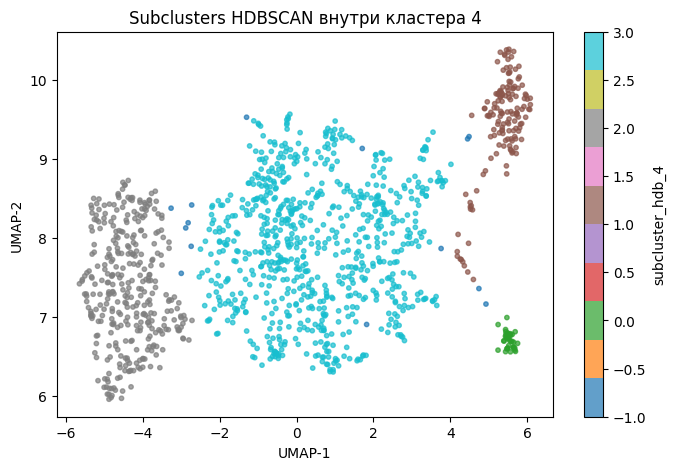

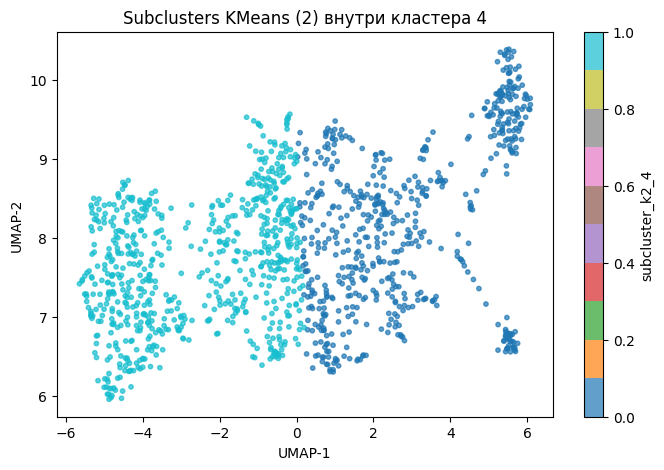

In [128]:
import matplotlib.pyplot as plt

# 1) График HDBSCAN-подкластеров внутри кластера 4
plt.figure(figsize=(8, 5))
plt.scatter(
    emb4[:, 0], emb4[:, 1],
    c=labels_sub_hdb,
    cmap='tab10',
    s=10,
    alpha=0.7
)
plt.title('Subclusters HDBSCAN внутри кластера 4')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(label='subcluster_hdb_4')
plt.show()

# 2) График KMeans-2-подкластеров внутри кластера 4
plt.figure(figsize=(8, 5))
plt.scatter(
    emb4[:, 0], emb4[:, 1],
    c=k2.labels_,
    cmap='tab10',
    s=10,
    alpha=0.7
)
plt.title('Subclusters KMeans (2) внутри кластера 4')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.colorbar(label='subcluster_k2_4')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


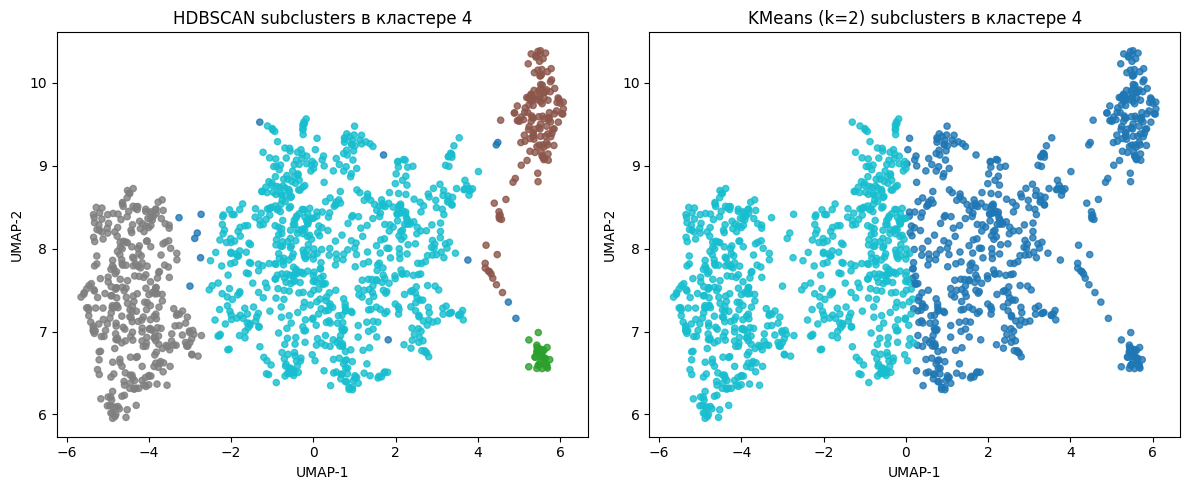

--- subcluster_hdb_4 ---
subcluster_hdb_4
-1.0     14
 0.0     38
 1.0    147
 2.0    343
 3.0    753
Name: count, dtype: int64



,acquirer_country_iso_ARE,acquirer_country_iso_ARM,acquirer_country_iso_BLR,acquirer_country_iso_CHN,acquirer_country_iso_GEO,acquirer_country_iso_ITA,acquirer_country_iso_KAZ,acquirer_country_iso_KGZ,acquirer_country_iso_TUR,acquirer_country_iso_USA,...,transaction_type_P2P_IN,transaction_type_P2P_OUT,transaction_type_POS,transaction_type_SALARY,unique_merchant_ids,unique_merchant_mccs,wallet_type_Apple Pay,wallet_type_Bank's QR,wallet_type_Google Pay,wallet_type_Samsung Pay
subcluster_hdb_4,,,,,,,,,,,,,,,,,,,,,
-1.0,0.000082,0.000258,0.0,0.0,0.0,0.00015,0.998,0.0,0.000964,0.000257,...,0.058792,0.058872,0.433595,0.002177,307.785714,33.142857,0.1218,0.251032,0.122023,0.119816
0.0,0.00092,0.001213,0.000845,0.001523,0.000774,0.001038,0.989104,0.001376,0.001325,0.000916,...,0.049579,0.051503,0.150315,0.004015,182.684211,31.289474,0.046315,0.090062,0.04746,0.046318
1.0,0.000109,0.000134,0.000293,0.000106,0.000092,0.000114,0.998596,0.000098,0.000285,0.000078,...,0.141907,0.142513,0.128906,0.001172,410.346939,35.428571,0.169216,0.084843,0.168863,0.168555
2.0,0.000001,0.000005,0.000002,0.000003,0.0,0.000004,0.999963,0.000005,0.000006,0.000005,...,0.01207,0.012161,0.82722,0.000756,463.568513,35.857143,0.099022,0.461874,0.098576,0.099318
3.0,0.000106,0.00006,0.000054,0.000074,0.000111,0.000097,0.999225,0.000054,0.000052,0.000077,...,0.060268,0.060216,0.38558,0.00235,375.532537,34.946879,0.120489,0.207843,0.120856,0.120833


--- subcluster_k2_4 ---
subcluster_k2_4
0.0    601
1.0    694
Name: count, dtype: int64



,acquirer_country_iso_ARE,acquirer_country_iso_ARM,acquirer_country_iso_BLR,acquirer_country_iso_CHN,acquirer_country_iso_GEO,acquirer_country_iso_ITA,acquirer_country_iso_KAZ,acquirer_country_iso_KGZ,acquirer_country_iso_TUR,acquirer_country_iso_USA,...,transaction_type_P2P_IN,transaction_type_P2P_OUT,transaction_type_POS,transaction_type_SALARY,unique_merchant_ids,unique_merchant_mccs,wallet_type_Apple Pay,wallet_type_Bank's QR,wallet_type_Google Pay,wallet_type_Samsung Pay
subcluster_k2_4,,,,,,,,,,,,,,,,,,,,,
0.0,0.000209,0.00018,0.000184,0.000201,0.000201,0.000213,0.998053,0.000169,0.000235,0.000167,...,0.085662,0.086094,0.260491,0.00233,364.938436,34.815308,0.137725,0.145645,0.138144,0.138201
1.0,0.00001,0.000011,0.000009,0.000013,0.000009,0.000007,0.999893,0.000011,0.000009,0.000012,...,0.031133,0.030983,0.645899,0.001418,423.665706,35.376081,0.101239,0.355627,0.101047,0.101167


Silhouette (KMeans k=2): 0.49693626


In [129]:
# 1) Импорты
import pandas as pd
import numpy as np
from umap import UMAP
import hdbscan
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 2) Фильтрация клиентов кластера 4
mask4 = df_segments['cluster_hdb'] == 4
X4 = X[mask4.values]
idx4 = df_segments.index[mask4]

# 3) Масштабирование
X4_scaled = preprocessor.transform(X4)

# 4) UMAP-эмбеддинг для этой подвыборки
umap4 = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_SEED)
emb4 = umap4.fit_transform(X4_scaled)

# 5A) HDBSCAN субкластеры
sub_hdb = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=5, gen_min_span_tree=True)
labels_sub_hdb = sub_hdb.fit_predict(emb4)
df_segments.loc[idx4, 'subcluster_hdb_4'] = labels_sub_hdb

# 5B) KMeans (k=2) субкластеры
k2 = KMeans(n_clusters=2, random_state=RANDOM_SEED)
labels_k2 = k2.fit_predict(emb4)
df_segments.loc[idx4, 'subcluster_k2_4'] = labels_k2

# 6) Визуализация
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(emb4[:,0], emb4[:,1], c=labels_sub_hdb, cmap='tab10', s=20, alpha=0.8)
plt.title('HDBSCAN subclusters в кластере 4'); plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')

plt.subplot(1, 2, 2)
plt.scatter(emb4[:,0], emb4[:,1], c=labels_k2, cmap='tab10', s=20, alpha=0.8)
plt.title('KMeans (k=2) subclusters в кластере 4'); plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')

plt.tight_layout(); plt.show()

# 7) Быстрый обзор
def summarize_sub(df, label):
    print(f"--- {label} ---")
    print(df[label].value_counts().sort_index(), end='\n\n')
    cols = df.columns.difference(['umap_x','umap_y','cluster_hdb'])
    display(df.groupby(label)[cols].mean())

sub_df = df_segments[df_segments['cluster_hdb'] == 4]
summarize_sub(sub_df, 'subcluster_hdb_4')
summarize_sub(sub_df, 'subcluster_k2_4')

# 8) Silhouette score для KMeans (опционально)
from sklearn.metrics import silhouette_score
print("Silhouette (KMeans k=2):", silhouette_score(emb4, labels_k2))